<a href="https://colab.research.google.com/github/samer-glitch/TADP-Cluster-Computing/blob/main/Illustrattions_based_on_completed_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using ZIP: /content/TADP_EXPERIMENT_A1_TADP-A-v16.9-5SEED-REDUCED-UNIQUE-3ROUND-EXACTPARITY-GXSCHEMA-POC-DQONLY-CRITICALWAC-28F_RESULTS.zip
Using ZIP: /content/TADP_EXPERIMENT_A1_TADP-EQUIV-AUDIT-v16.11-3SEED-4ROUND-NAIVE-GX-AA-CENTRAL-FEDERATED_RESULTS.zip
Saved: /content/tadp_rq1_figures/Figure_RQ1_Main_K10_AllScenarios.png
        pixels = 8913 x 4722, embedded dpi = (599.9988, 599.9988)
Saved: /content/tadp_rq1_figures/Figure_RQ1_Main_K10_AllScenarios.pdf


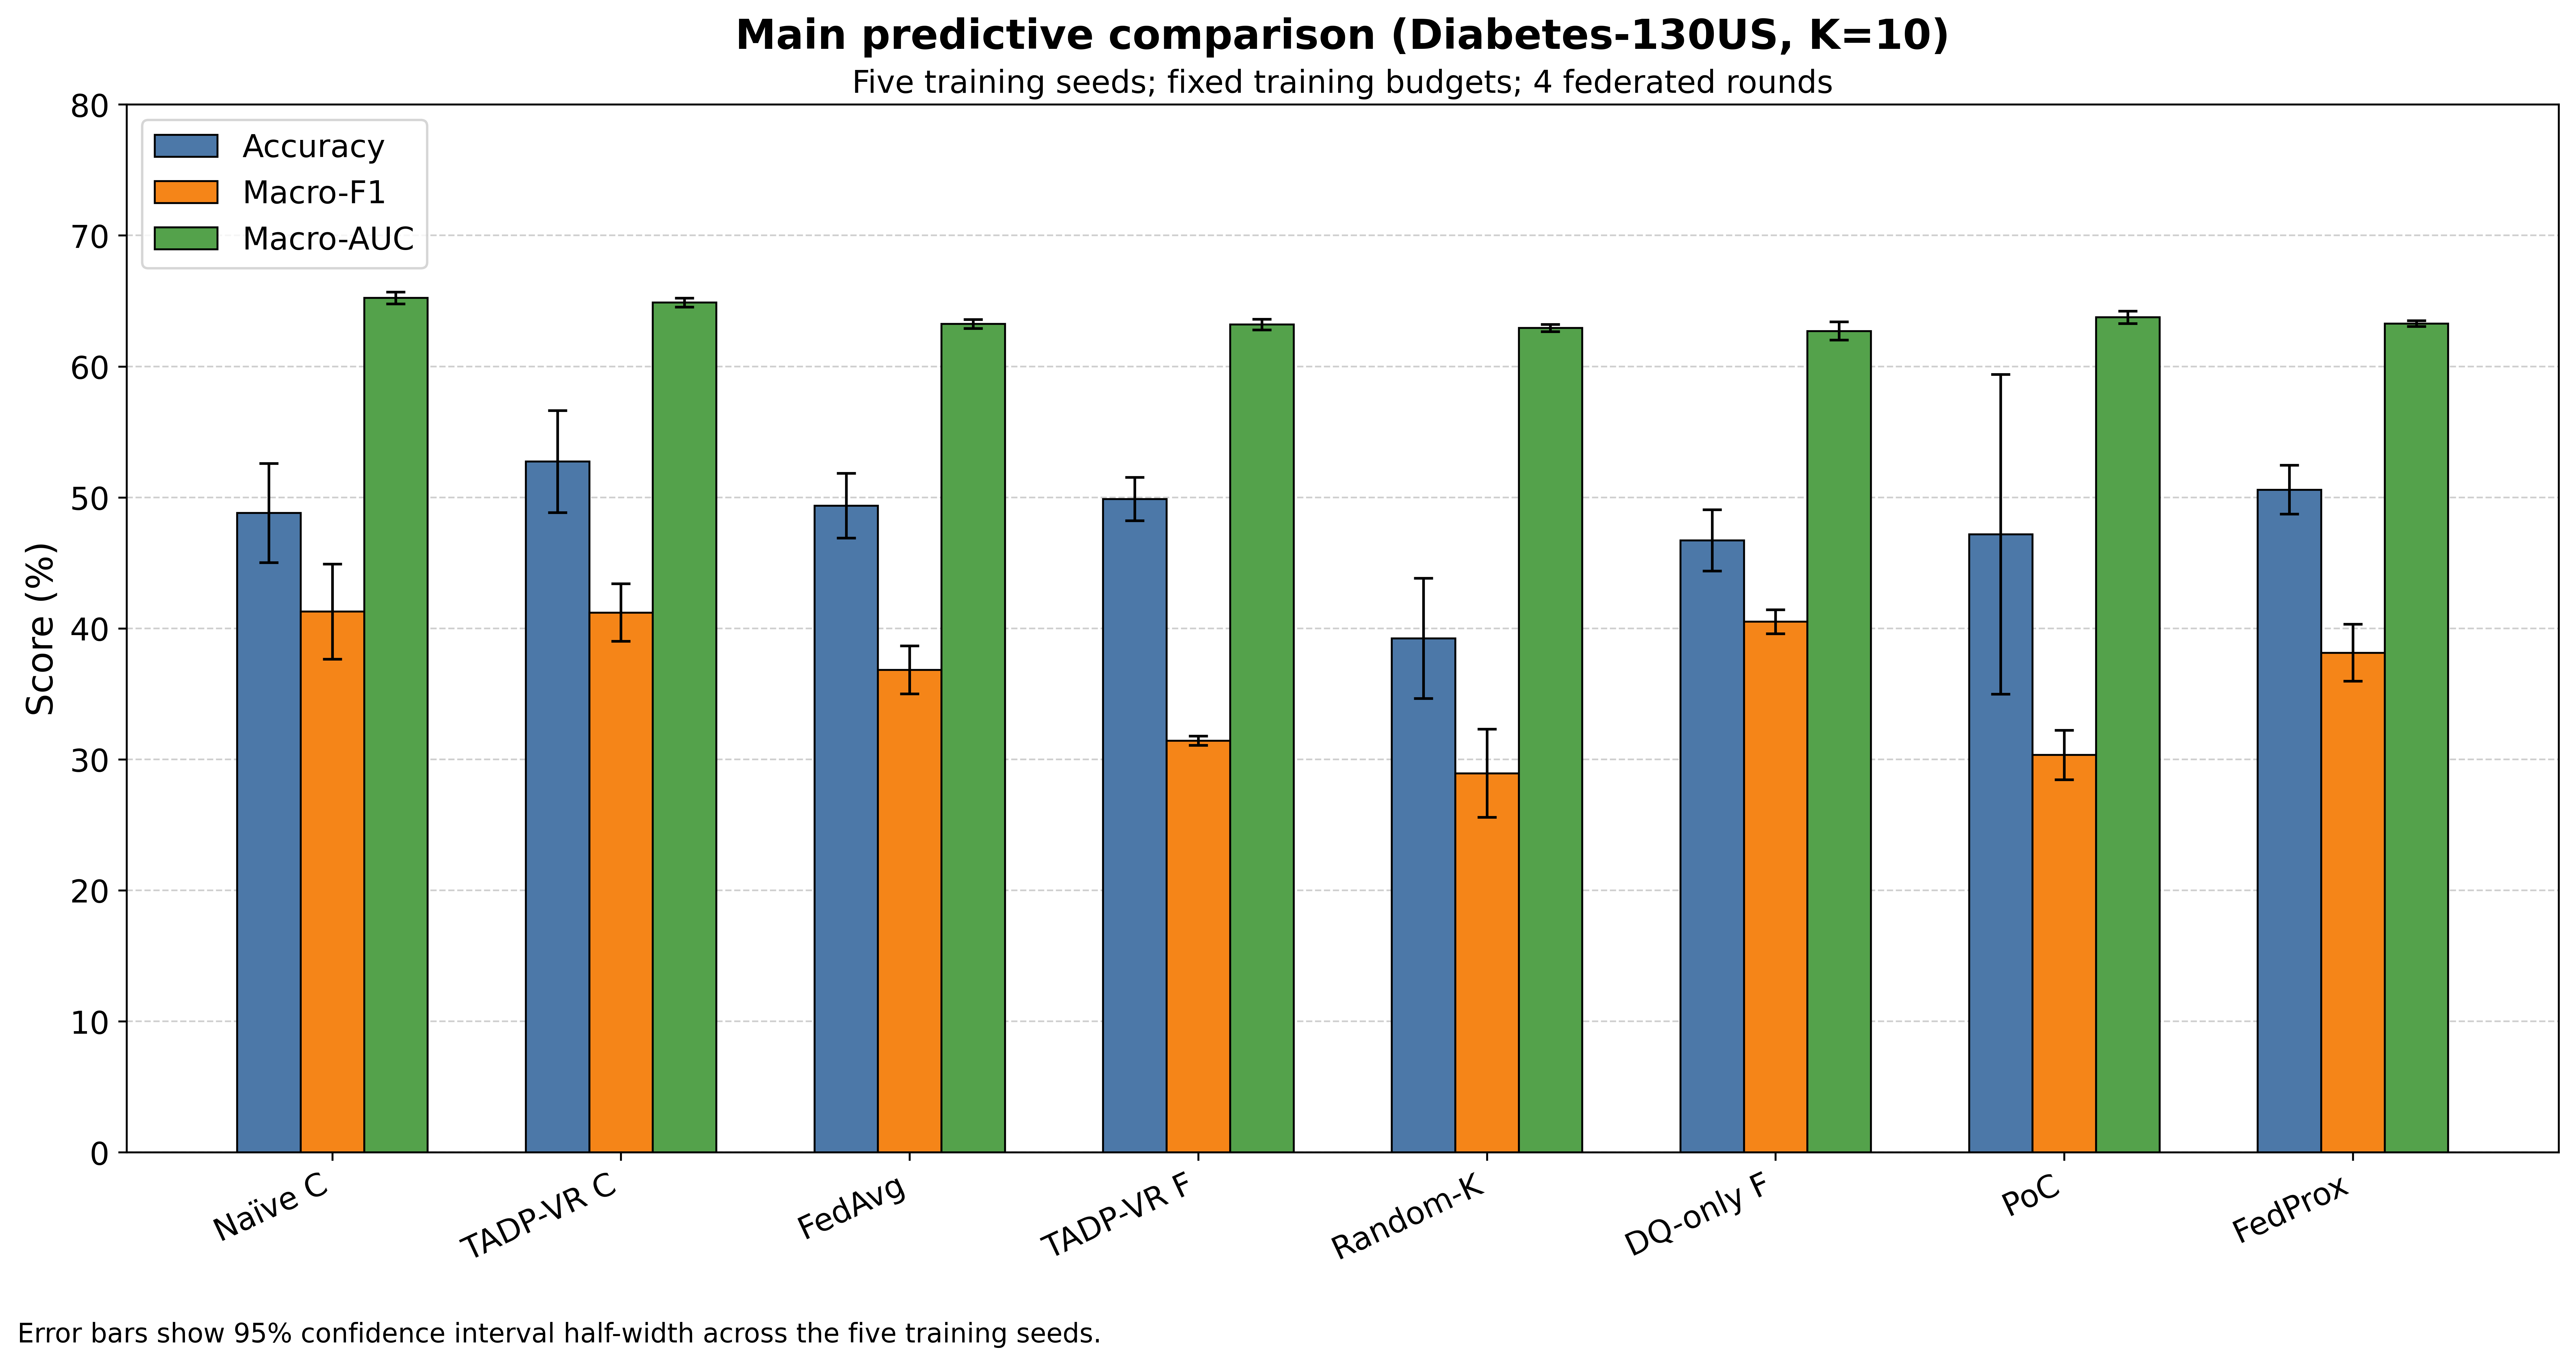

Saved: /content/tadp_rq1_figures/Figure_RQ1_AllClient_Equivalence_Audit.png
        pixels = 8913 x 4722, embedded dpi = (599.9988, 599.9988)
Saved: /content/tadp_rq1_figures/Figure_RQ1_AllClient_Equivalence_Audit.pdf


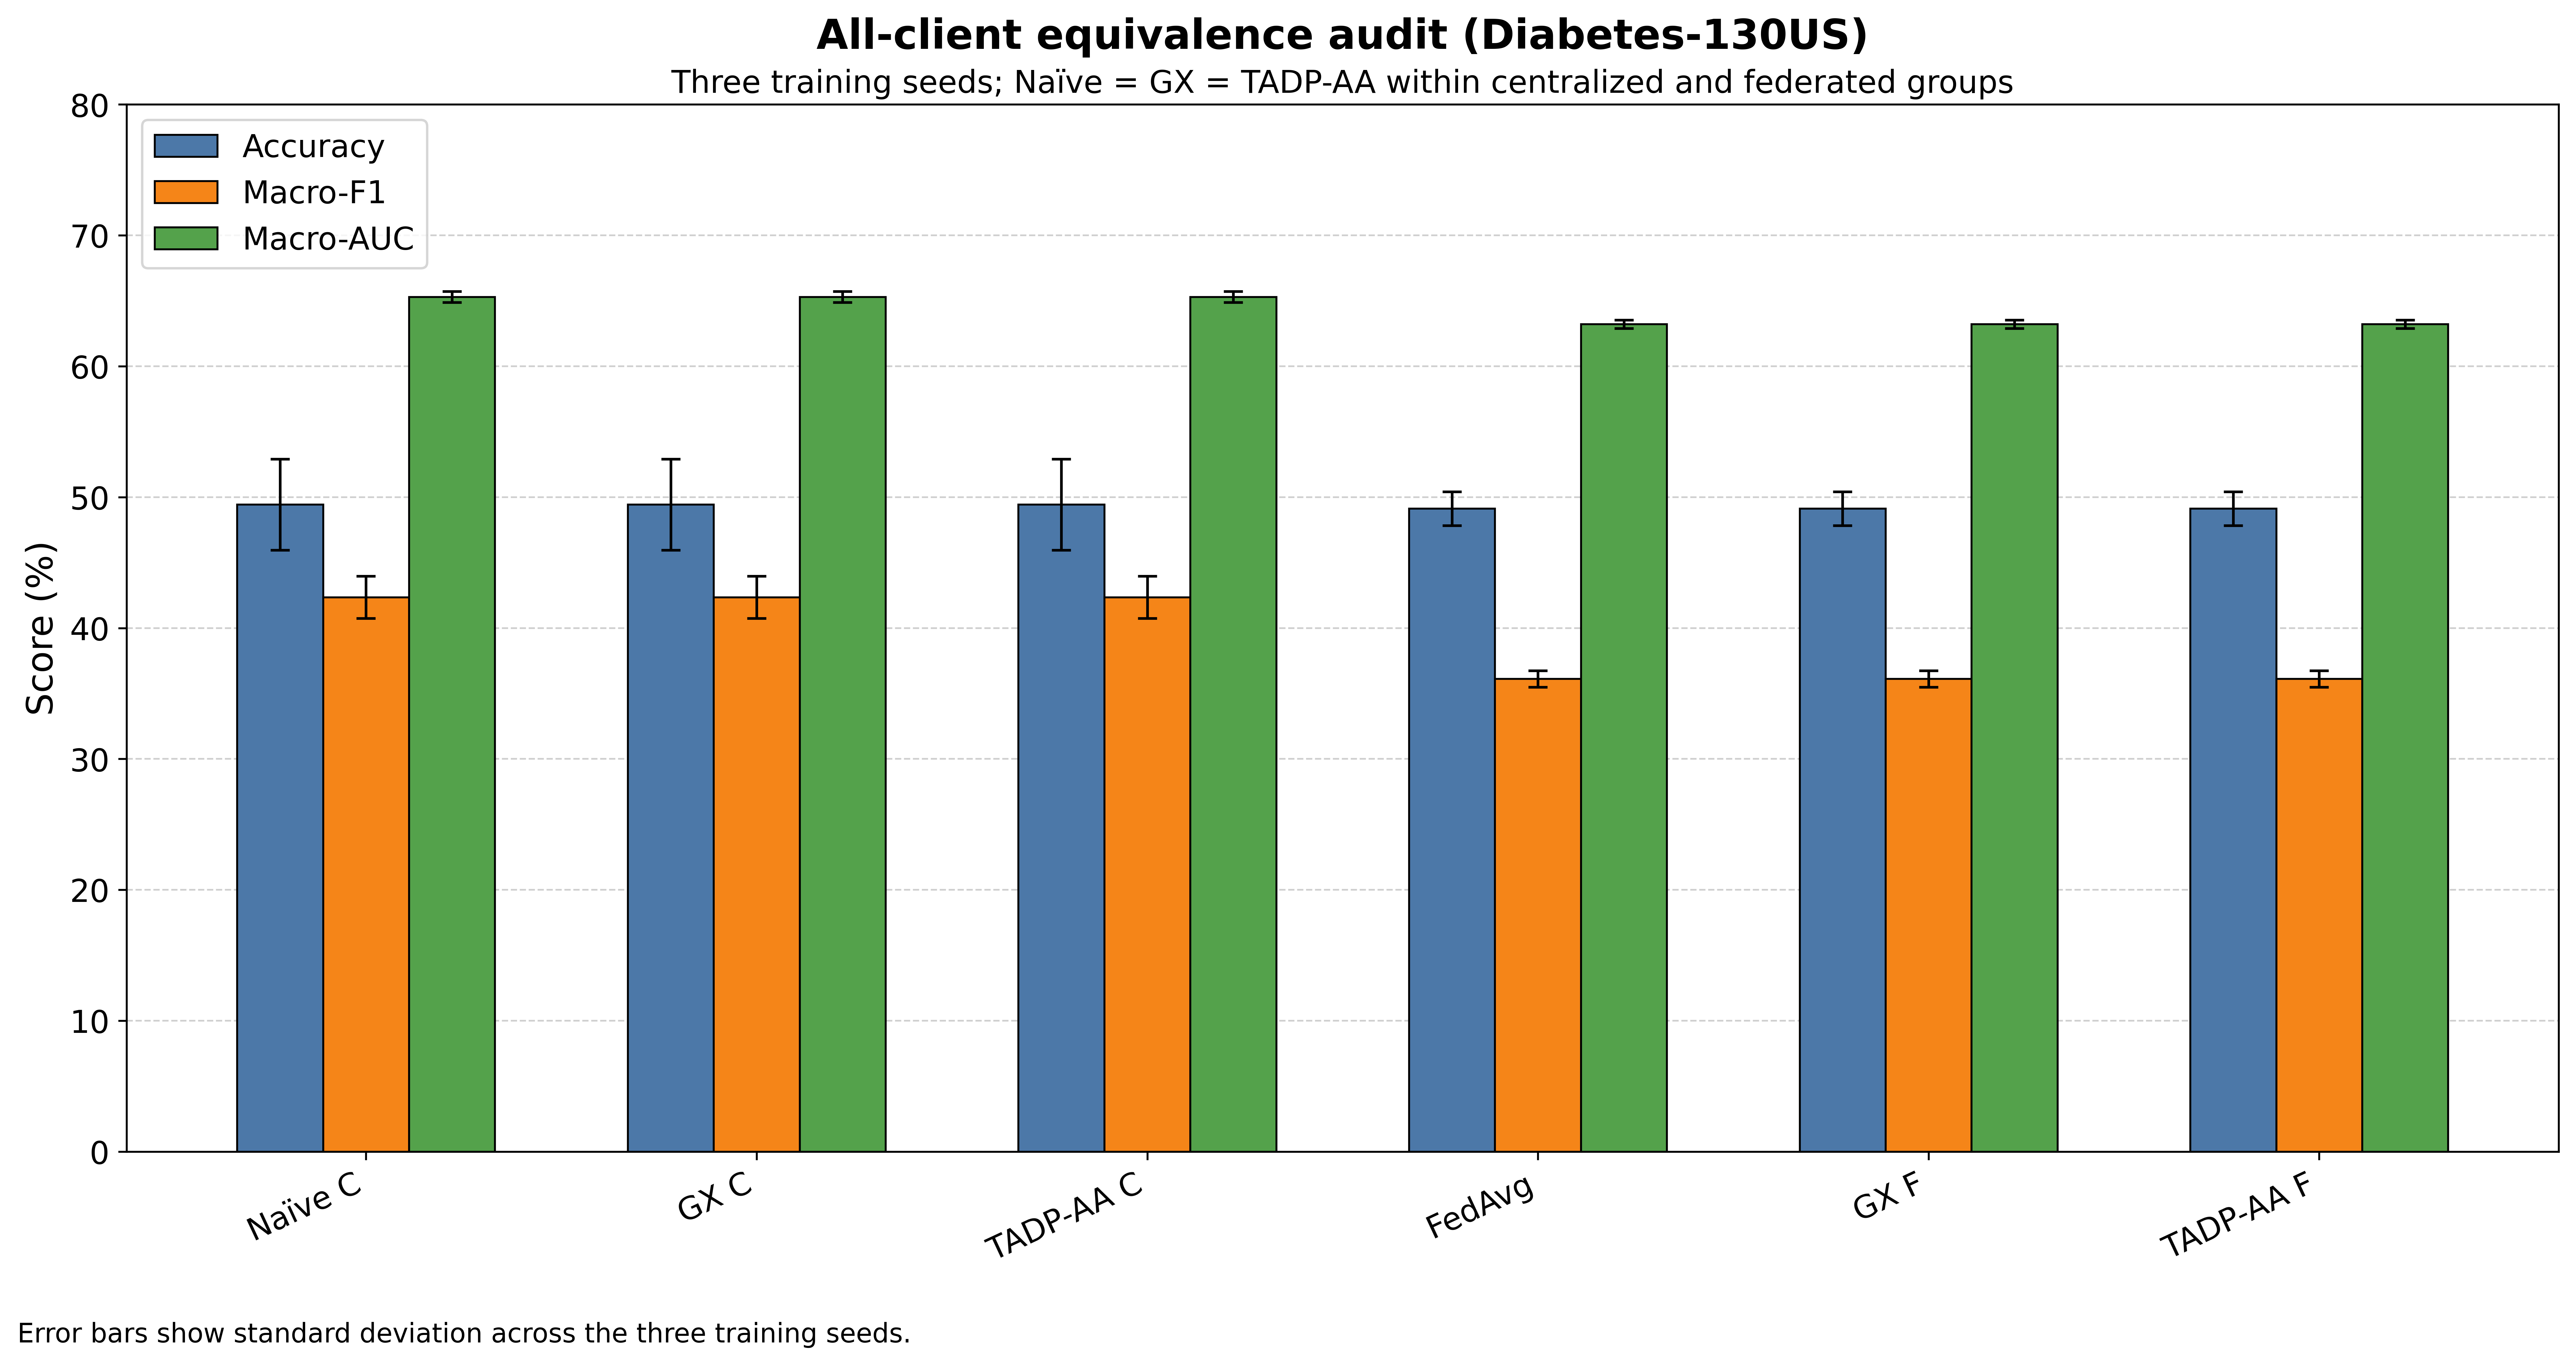


=== Main K=10 figure table ===
                     accuracy_mean  f1_macro_mean  roc_auc_ovr_macro_mean  \
scenario                                                                    
Naïve Centralized           0.4882         0.4129                  0.6523   
TADP-VR Centralized         0.5275         0.4122                  0.6488   
Vanilla FedAvg              0.4937         0.3684                  0.6325   
TADP-VR Federated           0.4988         0.3144                  0.6320   
Random-K                    0.3924         0.2895                  0.6295   
DQ-only Federated           0.4673         0.4052                  0.6272   
Power-of-Choice             0.4720         0.3035                  0.6375   
FedProx                     0.5060         0.3815                  0.6328   

                     runtime_s_mean  communication_mb_mean  energy_wh_mean  
scenario                                                                    
Naïve Centralized          641.5159        

In [ ]:
# ============================================================
# RQ1 FIGURES FROM FINAL RESULT ZIP FILES
# - 600 DPI output (PNG + PDF)
# - Larger fonts throughout
# - Title anchored to the axes (no stranding)
# - Figure 1: Main K=10 Diabetes experiment (8 scenarios, 5 seeds, 4 rounds)
# - Figure 2: All-client equivalence audit (6 scenarios, 3 seeds)
# ============================================================

import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1) GLOBAL STYLE / DPI / FONT SIZES
# ------------------------------------------------------------
DPI = 600

matplotlib.rcParams.update({
    "figure.dpi":        DPI,
    "savefig.dpi":       DPI,
    "figure.figsize":    (15, 8.0),
    "savefig.bbox":      "tight",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "font.family":       "DejaVu Sans",
    "font.size":         13,
    "axes.titlesize":    13,
    "axes.labelsize":    15,
    "xtick.labelsize":   13,
    "ytick.labelsize":   13,
    "legend.fontsize":   13,
})

OUTPUT_DIR = "/content/tadp_rq1_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2) LOCATE THE ZIP FILES (robust to (1), (2) suffixes)
# ------------------------------------------------------------
def find_zip(pattern):
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No ZIP matching: {pattern}")
    print("Using ZIP:", matches[0])
    return matches[0]

MAIN_ZIP = find_zip(
    "/content/TADP_EXPERIMENT_A1_TADP-A-v16.9-5SEED-REDUCED-UNIQUE-3ROUND-"
    "EXACTPARITY-GXSCHEMA-POC-DQONLY-CRITICALWAC-28F_RESULTS*.zip"
)
EQUIV_ZIP = find_zip(
    "/content/TADP_EXPERIMENT_A1_TADP-EQUIV-AUDIT-v16.11-3SEED-4ROUND-"
    "NAIVE-GX-AA-CENTRAL-FEDERATED_RESULTS*.zip"
)

# ------------------------------------------------------------
# 3) HELPERS
# ------------------------------------------------------------
def read_csv_from_zip(zip_path, csv_name):
    """Find csv_name anywhere inside the zip (top-level or nested)."""
    with zipfile.ZipFile(zip_path, "r") as zf:
        candidates = [n for n in zf.namelist() if n.endswith(csv_name)]
        if not candidates:
            raise FileNotFoundError(
                f"{csv_name} not found in {zip_path}. "
                f"Available: {[n for n in zf.namelist() if n.endswith('.csv')]}"
            )
        candidates.sort(key=lambda n: n.count("/"))
        with zf.open(candidates[0]) as f:
            return pd.read_csv(f)

def save_figure(fig, out_base, dpi=DPI):
    png_path = os.path.join(OUTPUT_DIR, out_base + ".png")
    pdf_path = os.path.join(OUTPUT_DIR, out_base + ".pdf")

    # NOTE: no metadata={"dpi": ...} — PIL rejects non-str values.
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight")

    with Image.open(png_path) as im:
        w, h = im.size
        print(f"Saved: {png_path}")
        print(f"        pixels = {w} x {h}, embedded dpi = {im.info.get('dpi','n/a')}")
    print(f"Saved: {pdf_path}")

def short_label(name):
    mapping = {
        "Naïve Centralized": "Naïve C",
        "TADP-VR Centralized": "TADP-VR C",
        "Vanilla FedAvg": "FedAvg",
        "TADP-VR Federated": "TADP-VR F",
        "Random-K": "Random-K",
        "DQ-only Federated": "DQ-only F",
        "Power-of-Choice": "PoC",
        "FedProx": "FedProx",
        "Great Expectations Centralized": "GX C",
        "Great Expectations Federated": "GX F",
        "TADP-AA Centralized": "TADP-AA C",
        "TADP-AA Federated": "TADP-AA F",
    }
    return mapping.get(name, name)

def grouped_barplot(
    df, scenario_col, metrics, metric_labels, title, subtitle,
    scenario_order, out_name, error_cols=None,
    ylabel="Score (%)", ylim=(0, 100), footnote=None,
    fs_title=17, fs_subtitle=13, fs_xtick=13, fs_ytick=13,
    fs_ylabel=15, fs_legend=13, fs_footnote=11,
):
    plot_df = df.copy().set_index(scenario_col).loc[scenario_order].reset_index()

    x = np.arange(len(plot_df))
    n_metrics = len(metrics)
    width = 0.22 if n_metrics == 3 else 0.18

    fig, ax = plt.subplots(figsize=(15, 8.0), dpi=DPI)
    colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"]

    for i, metric in enumerate(metrics):
        vals = plot_df[metric].values * 100.0
        errs = plot_df[error_cols[i]].values * 100.0 if (error_cols and error_cols[i]) else None
        offset = (i - (n_metrics - 1) / 2) * width
        ax.bar(
            x + offset, vals, width=width, label=metric_labels[i],
            color=colors[i], edgecolor="black", linewidth=0.8,
            yerr=errs, capsize=4,
            error_kw={"elinewidth": 1.1, "capthick": 1.1},
        )

    ax.set_xticks(x)
    ax.set_xticklabels([short_label(s) for s in plot_df[scenario_col]],
                       rotation=25, ha="right", fontsize=fs_xtick)
    ax.set_ylabel(ylabel, fontsize=fs_ylabel)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="y", labelsize=fs_ytick)

    # --- Title and subtitle anchored to the axes (tight, no stranding) ---
    ax.text(0.5, 1.045, title, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=fs_title, weight="bold")
    ax.text(0.5, 1.005, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=fs_subtitle)

    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=True, fontsize=fs_legend, loc="upper left")

    if footnote:
        fig.text(0.01, -0.03, footnote, fontsize=fs_footnote, ha="left")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_figure(fig, out_name)
    plt.show()

# ------------------------------------------------------------
# 4) FIGURE 1 — MAIN K=10, 5 SEEDS, 4 ROUNDS
# ------------------------------------------------------------
main_summary = read_csv_from_zip(MAIN_ZIP, "performance_summary_mean_sd_ci95.csv")

main_order = [
    "Naïve Centralized",
    "TADP-VR Centralized",
    "Vanilla FedAvg",
    "TADP-VR Federated",
    "Random-K",
    "DQ-only Federated",
    "Power-of-Choice",
    "FedProx",
]

main_metrics = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean"]
main_metric_labels = ["Accuracy", "Macro-F1", "Macro-AUC"]

main_error_cols = []
for metric in ["accuracy", "f1_macro", "roc_auc_ovr_macro"]:
    half_width = (main_summary[f"{metric}_ci95_high"]
                  - main_summary[f"{metric}_ci95_low"]) / 2.0
    col_name = f"{metric}_ci95_halfwidth"
    main_summary[col_name] = half_width
    main_error_cols.append(col_name)

grouped_barplot(
    df=main_summary,
    scenario_col="scenario",
    metrics=main_metrics,
    metric_labels=main_metric_labels,
    title="Main predictive comparison (Diabetes-130US, K=10)",
    subtitle="Five training seeds; fixed training budgets; 4 federated rounds",
    scenario_order=main_order,
    out_name="Figure_RQ1_Main_K10_AllScenarios",
    error_cols=main_error_cols,
    ylabel="Score (%)",
    ylim=(0, 80),
    footnote="Error bars show 95% confidence interval half-width across the five training seeds.",
)

# ------------------------------------------------------------
# 5) FIGURE 2 — ALL-CLIENT EQUIVALENCE AUDIT, 3 SEEDS
# ------------------------------------------------------------
equiv_runs = read_csv_from_zip(EQUIV_ZIP, "equivalence_audit_run_metrics.csv")

equiv_summary = (
    equiv_runs
    .groupby("scenario", as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_sd=("f1_macro", "std"),
        roc_auc_ovr_macro_mean=("roc_auc_ovr_macro", "mean"),
        roc_auc_ovr_macro_sd=("roc_auc_ovr_macro", "std"),
    )
)

equiv_order = [
    "Naïve Centralized",
    "Great Expectations Centralized",
    "TADP-AA Centralized",
    "Vanilla FedAvg",
    "Great Expectations Federated",
    "TADP-AA Federated",
]

equiv_metrics = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean"]
equiv_metric_labels = ["Accuracy", "Macro-F1", "Macro-AUC"]
equiv_error_cols = ["accuracy_sd", "f1_macro_sd", "roc_auc_ovr_macro_sd"]

grouped_barplot(
    df=equiv_summary,
    scenario_col="scenario",
    metrics=equiv_metrics,
    metric_labels=equiv_metric_labels,
    title="All-client equivalence audit (Diabetes-130US)",
    subtitle="Three training seeds; Naïve = GX = TADP-AA within centralized and federated groups",
    scenario_order=equiv_order,
    out_name="Figure_RQ1_AllClient_Equivalence_Audit",
    error_cols=equiv_error_cols,
    ylabel="Score (%)",
    ylim=(0, 80),
    footnote="Error bars show standard deviation across the three training seeds.",
)

# ------------------------------------------------------------
# 6) NUMERICAL TABLES (printed to console, for the manuscript)
# ------------------------------------------------------------
print("\n=== Main K=10 figure table ===")
display_cols_main = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean",
                     "runtime_s_mean", "communication_mb_mean", "energy_wh_mean"]
print(main_summary.set_index("scenario").loc[main_order][display_cols_main].round(4))

print("\n=== All-client equivalence figure table ===")
display_cols_equiv = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean"]
print(equiv_summary.set_index("scenario").loc[equiv_order][display_cols_equiv].round(4))

print("\nOutput files in:", OUTPUT_DIR)
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*"))):
    print("  ", p)

Using ZIP: /content/TADP_EXPERIMENT_A1_TADP-A-v16.9-5SEED-REDUCED-UNIQUE-3ROUND-EXACTPARITY-GXSCHEMA-POC-DQONLY-CRITICALWAC-28F_RESULTS.zip
Using ZIP: /content/TADP_EXPERIMENT_A1_TADP-EQUIV-AUDIT-v16.11-3SEED-4ROUND-NAIVE-GX-AA-CENTRAL-FEDERATED_RESULTS.zip
Saved: /content/tadp_rq1_figures/Figure_RQ1_Combined_TwoPanels.png
        pixels = 8968 x 8777, embedded dpi = (599.9988, 599.9988)
Saved: /content/tadp_rq1_figures/Figure_RQ1_Combined_TwoPanels.pdf


Saved: /content/tadp_rq1_figures/Figure_RQ1_Main_K10_AllScenarios.png
        pixels = 8913 x 4720, embedded dpi = (599.9988, 599.9988)
Saved: /content/tadp_rq1_figures/Figure_RQ1_Main_K10_AllScenarios.pdf


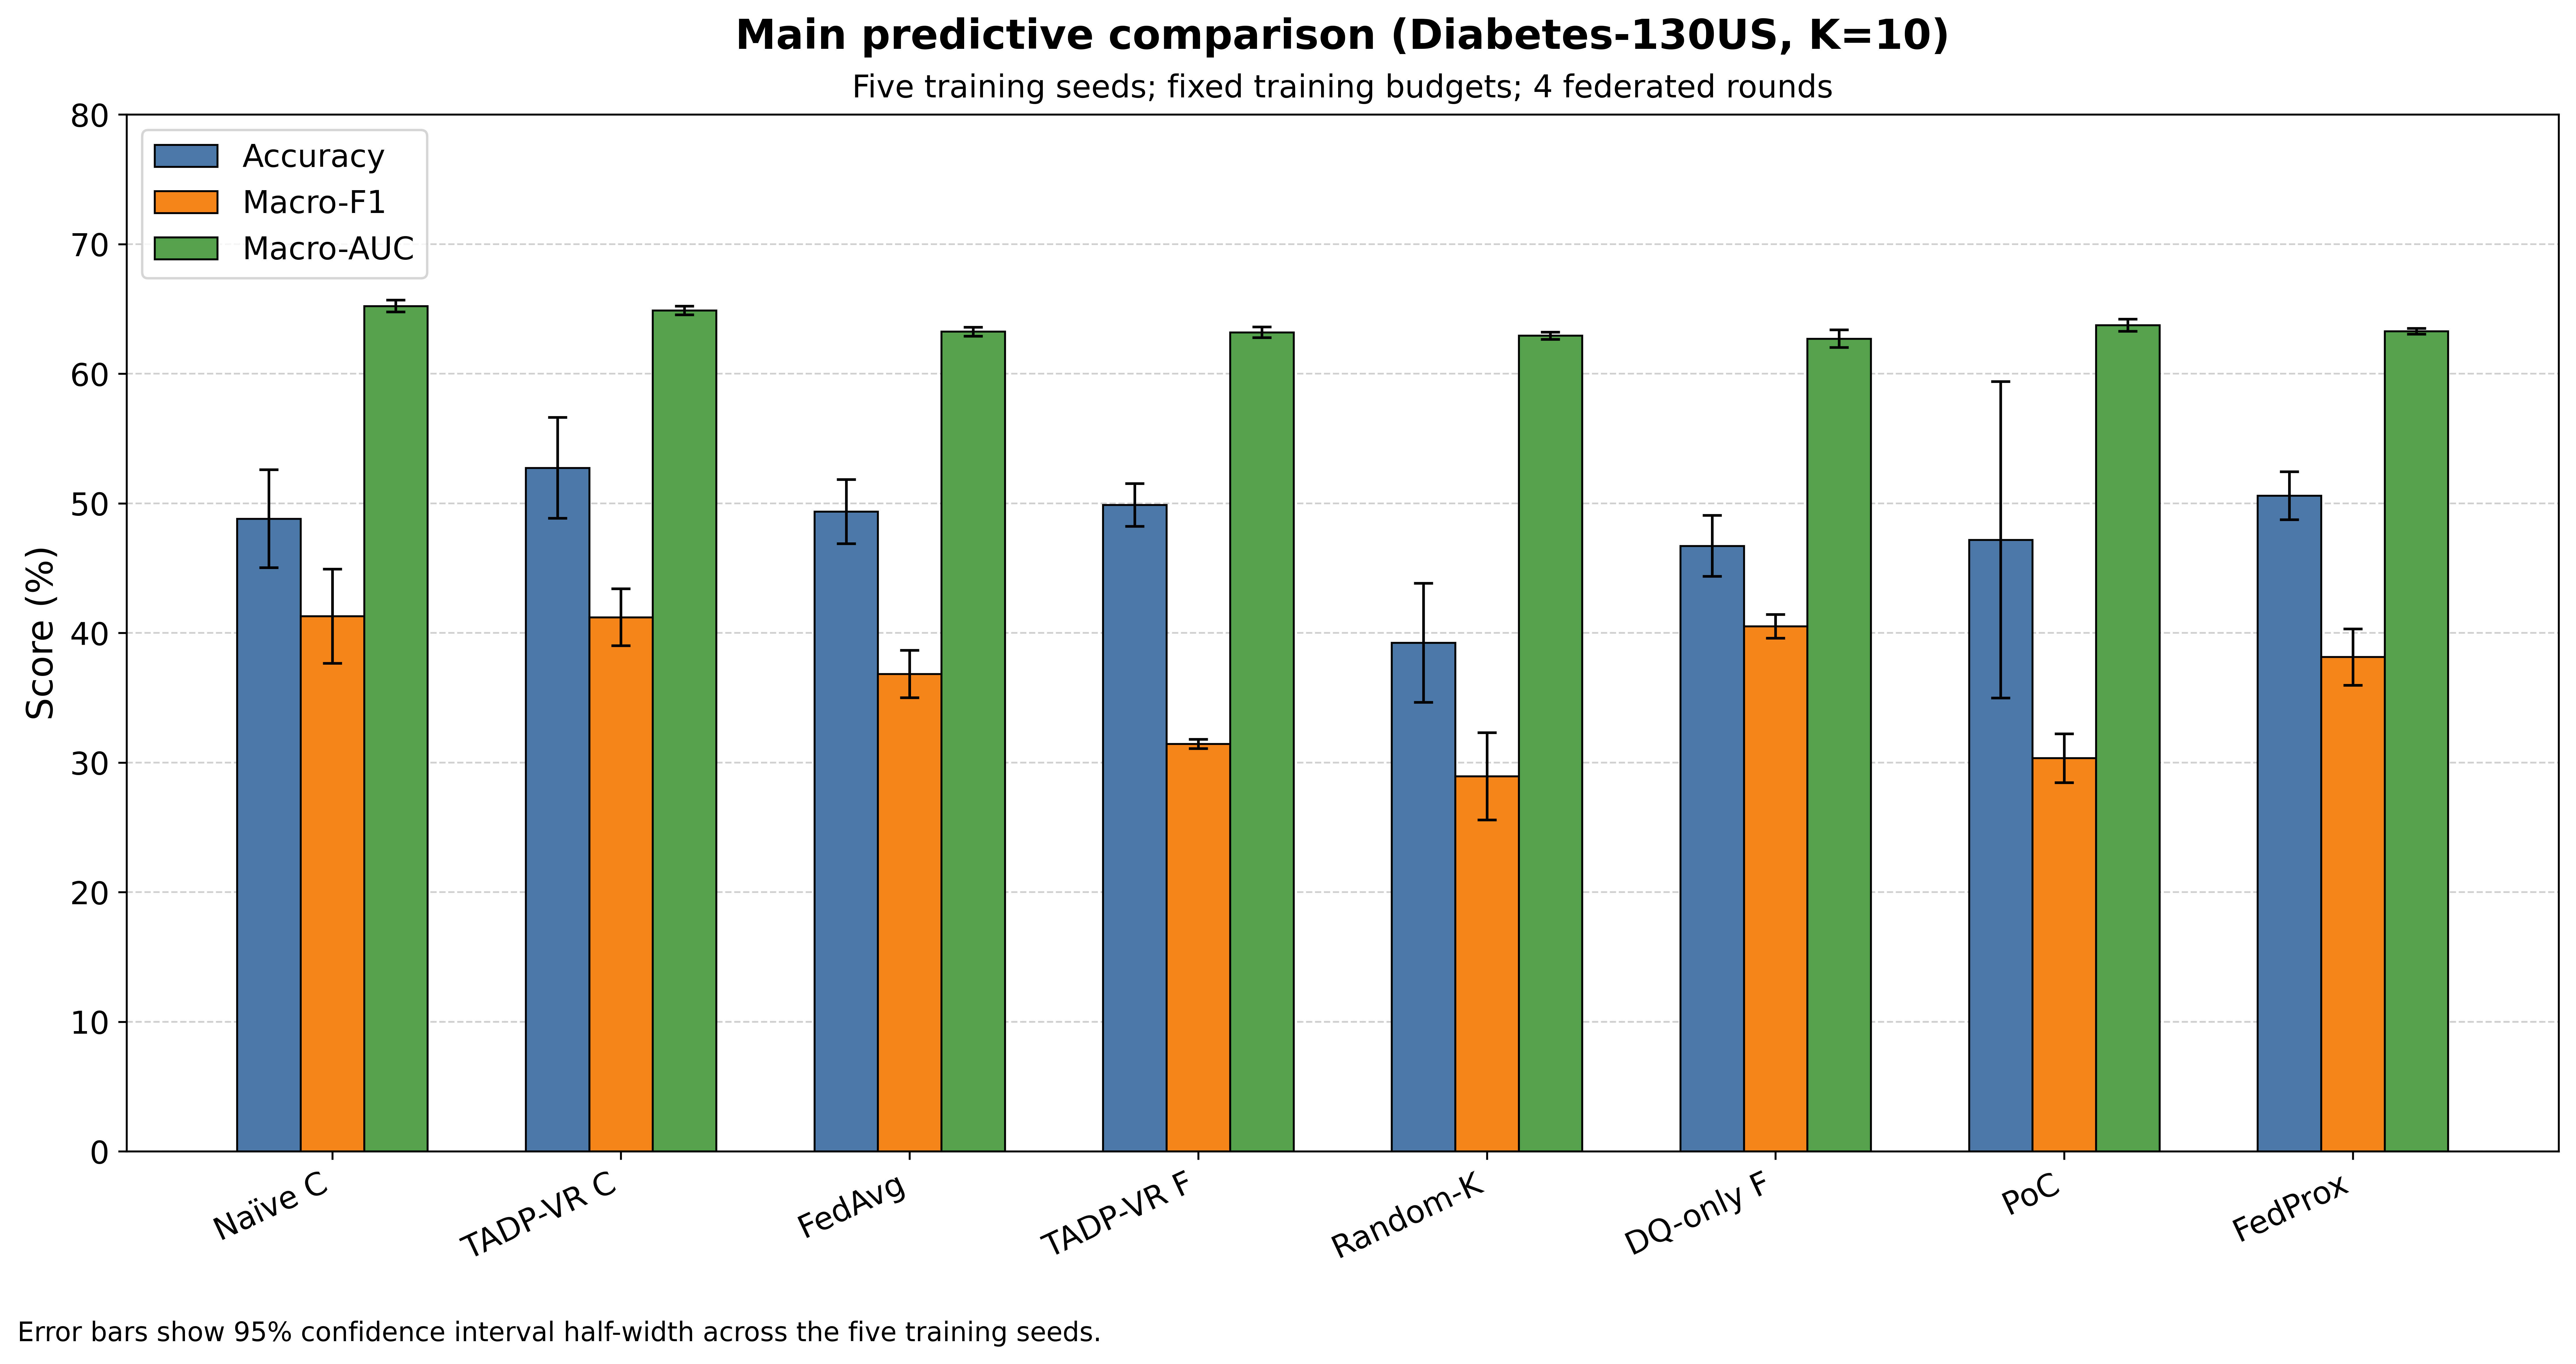

Saved: /content/tadp_rq1_figures/Figure_RQ1_AllClient_Equivalence_Audit.png
        pixels = 8913 x 4719, embedded dpi = (599.9988, 599.9988)
Saved: /content/tadp_rq1_figures/Figure_RQ1_AllClient_Equivalence_Audit.pdf


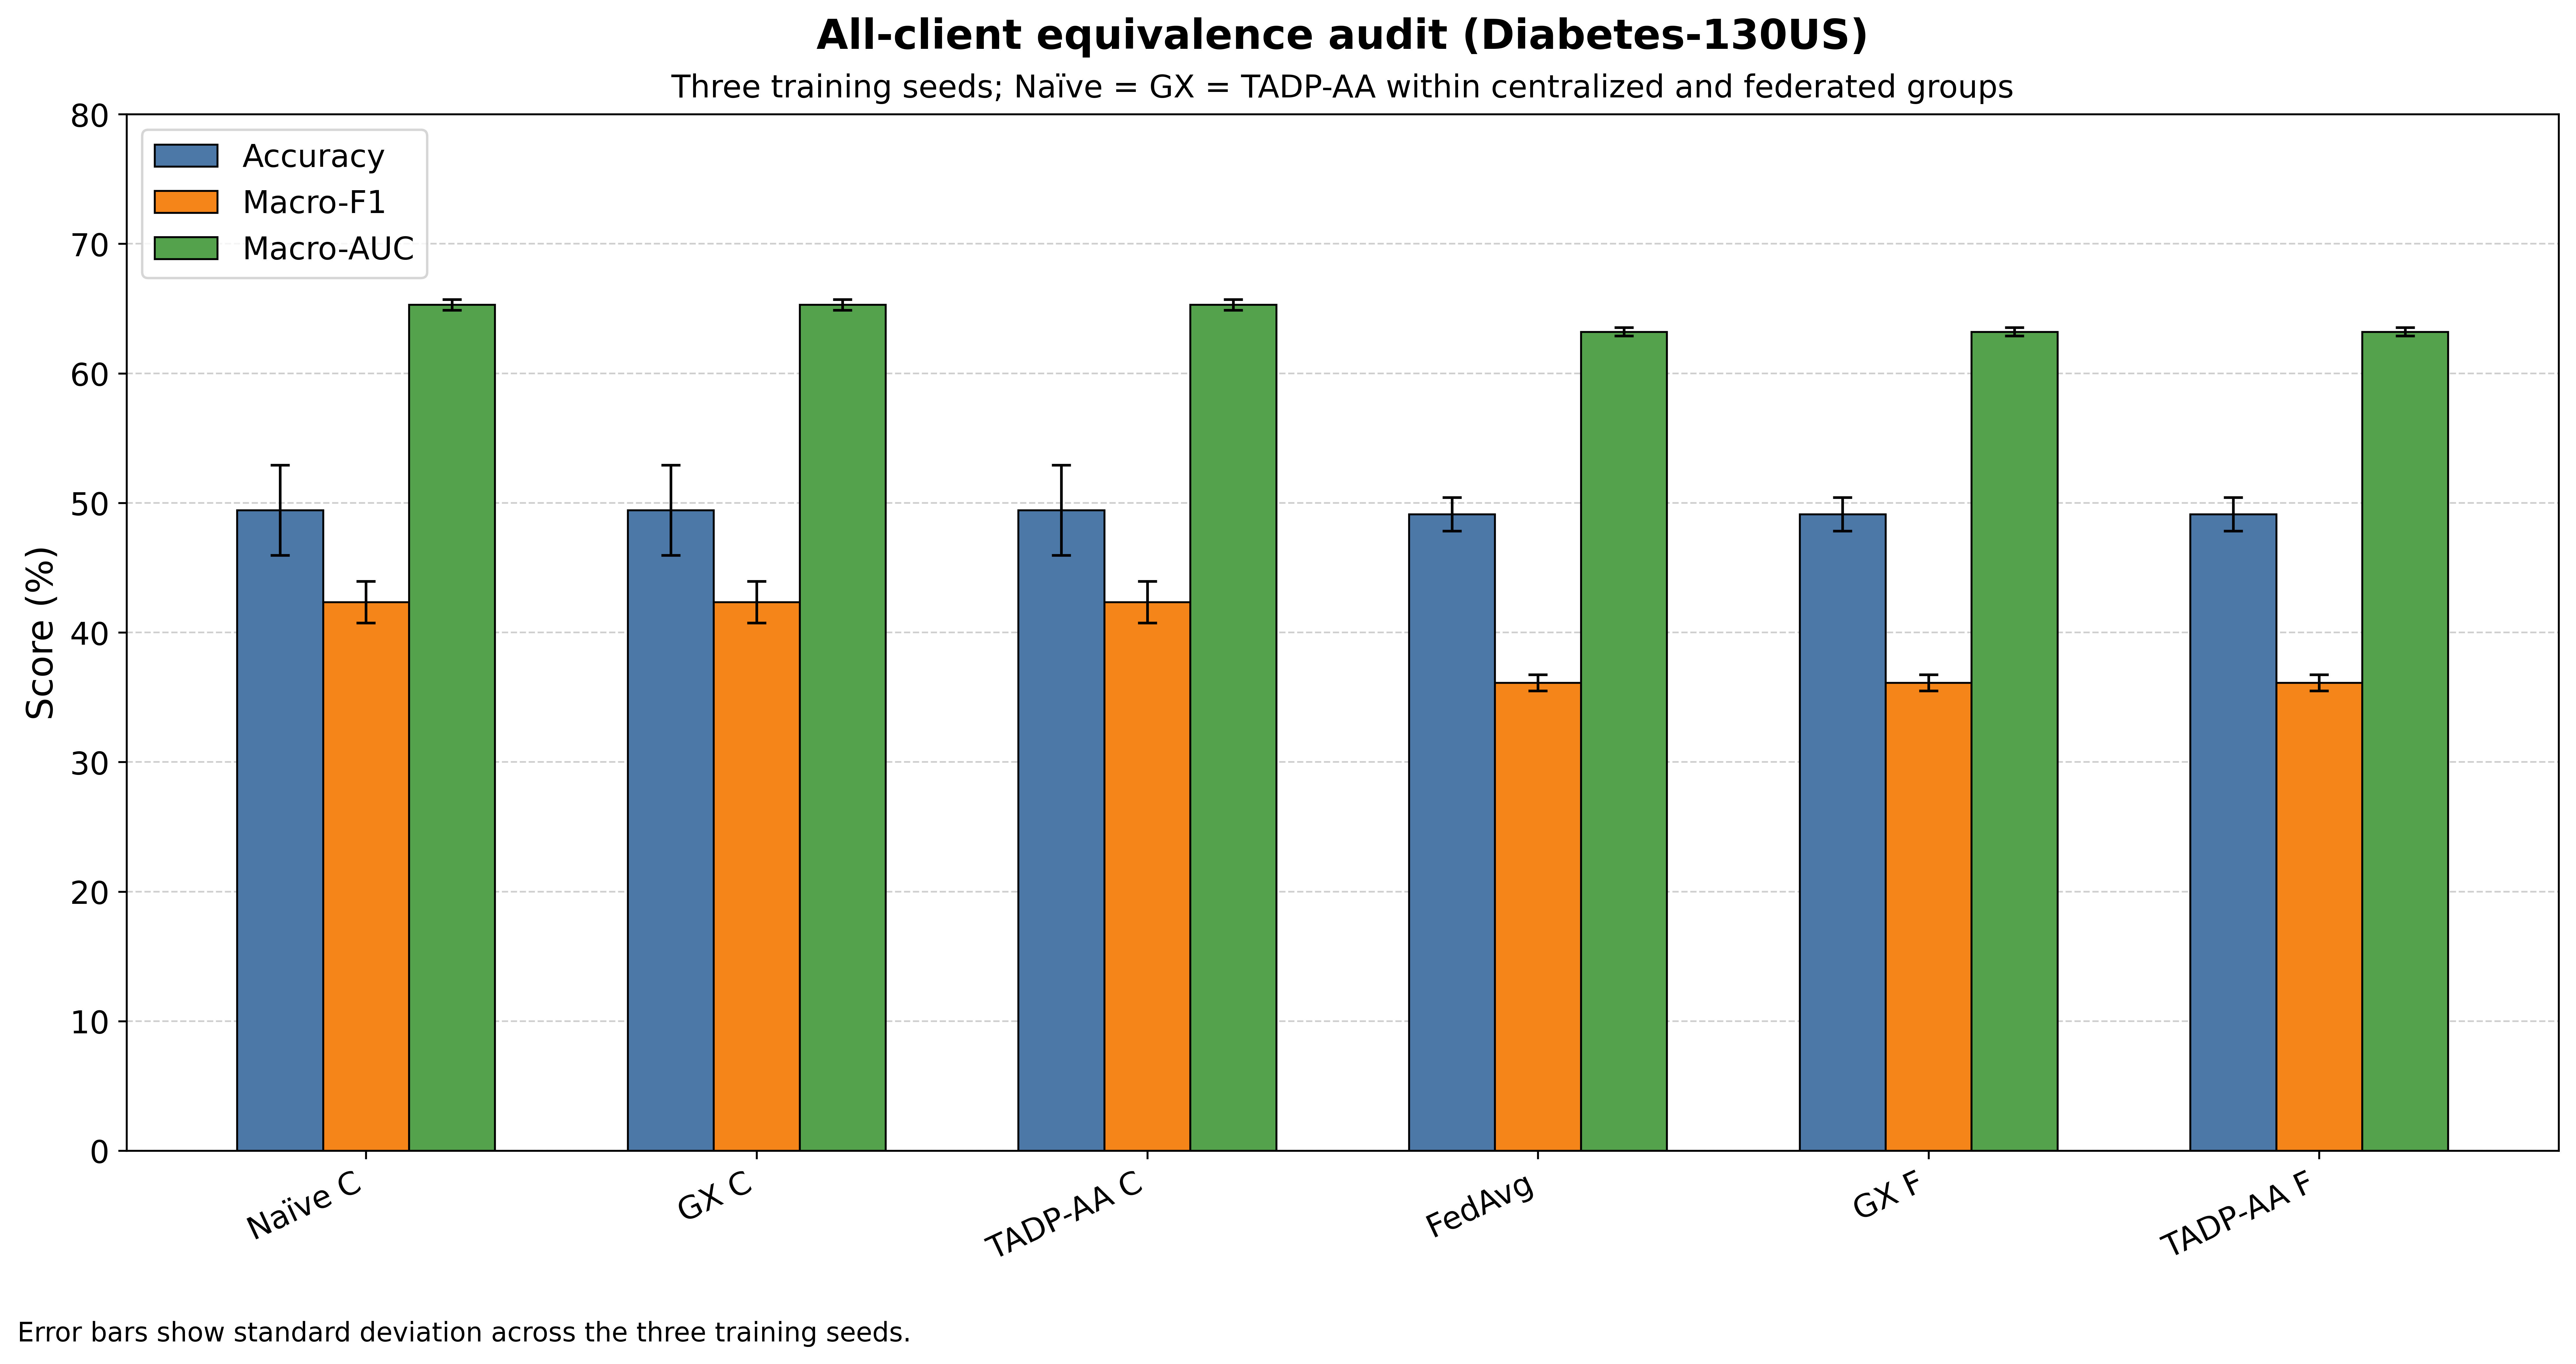


=== Main K=10 figure table ===
                     accuracy_mean  f1_macro_mean  roc_auc_ovr_macro_mean  \
scenario                                                                    
Naïve Centralized           0.4882         0.4129                  0.6523   
TADP-VR Centralized         0.5275         0.4122                  0.6488   
Vanilla FedAvg              0.4937         0.3684                  0.6325   
TADP-VR Federated           0.4988         0.3144                  0.6320   
Random-K                    0.3924         0.2895                  0.6295   
DQ-only Federated           0.4673         0.4052                  0.6272   
Power-of-Choice             0.4720         0.3035                  0.6375   
FedProx                     0.5060         0.3815                  0.6328   

                     runtime_s_mean  communication_mb_mean  energy_wh_mean  
scenario                                                                    
Naïve Centralized          641.5159        

In [ ]:
# ============================================================
# RQ1 FIGURES — COMBINED (two panels stacked vertically)
# - Panel A (top):    Main K=10 Diabetes experiment (8 scenarios, 5 seeds, 4 rounds)
# - Panel B (bottom): All-client equivalence audit (6 scenarios, 3 seeds)
# - 600 DPI, large fonts, tight title spacing
# ============================================================

import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1) GLOBAL STYLE / DPI / FONT SIZES
# ------------------------------------------------------------
DPI = 600

matplotlib.rcParams.update({
    "figure.dpi":        DPI,
    "savefig.dpi":       DPI,
    "savefig.bbox":      "tight",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "font.family":       "DejaVu Sans",
    "font.size":         13,
    "axes.titlesize":    13,
    "axes.labelsize":    15,
    "xtick.labelsize":   13,
    "ytick.labelsize":   13,
    "legend.fontsize":   13,
})

OUTPUT_DIR = "/content/tadp_rq1_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2) LOCATE THE ZIP FILES (robust to (1), (2) suffixes)
# ------------------------------------------------------------
def find_zip(pattern):
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No ZIP matching: {pattern}")
    print("Using ZIP:", matches[0])
    return matches[0]

MAIN_ZIP = find_zip(
    "/content/TADP_EXPERIMENT_A1_TADP-A-v16.9-5SEED-REDUCED-UNIQUE-3ROUND-"
    "EXACTPARITY-GXSCHEMA-POC-DQONLY-CRITICALWAC-28F_RESULTS*.zip"
)
EQUIV_ZIP = find_zip(
    "/content/TADP_EXPERIMENT_A1_TADP-EQUIV-AUDIT-v16.11-3SEED-4ROUND-"
    "NAIVE-GX-AA-CENTRAL-FEDERATED_RESULTS*.zip"
)

# ------------------------------------------------------------
# 3) HELPERS
# ------------------------------------------------------------
def read_csv_from_zip(zip_path, csv_name):
    with zipfile.ZipFile(zip_path, "r") as zf:
        candidates = [n for n in zf.namelist() if n.endswith(csv_name)]
        if not candidates:
            raise FileNotFoundError(
                f"{csv_name} not found in {zip_path}. "
                f"Available: {[n for n in zf.namelist() if n.endswith('.csv')]}"
            )
        candidates.sort(key=lambda n: n.count("/"))
        with zf.open(candidates[0]) as f:
            return pd.read_csv(f)

def save_figure(fig, out_base, dpi=DPI):
    png_path = os.path.join(OUTPUT_DIR, out_base + ".png")
    pdf_path = os.path.join(OUTPUT_DIR, out_base + ".pdf")
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight")
    with Image.open(png_path) as im:
        w, h = im.size
        print(f"Saved: {png_path}")
        print(f"        pixels = {w} x {h}, embedded dpi = {im.info.get('dpi','n/a')}")
    print(f"Saved: {pdf_path}")

def short_label(name):
    mapping = {
        "Naïve Centralized": "Naïve C",
        "TADP-VR Centralized": "TADP-VR C",
        "Vanilla FedAvg": "FedAvg",
        "TADP-VR Federated": "TADP-VR F",
        "Random-K": "Random-K",
        "DQ-only Federated": "DQ-only F",
        "Power-of-Choice": "PoC",
        "FedProx": "FedProx",
        "Great Expectations Centralized": "GX C",
        "Great Expectations Federated": "GX F",
        "TADP-AA Centralized": "TADP-AA C",
        "TADP-AA Federated": "TADP-AA F",
    }
    return mapping.get(name, name)

def draw_grouped_barplot_on_axes(
    ax, df, scenario_col, metrics, metric_labels,
    title, subtitle, scenario_order,
    error_cols=None, ylabel="Score (%)", ylim=(0, 100),
    panel_letter=None,
    fs_title=17, fs_subtitle=13, fs_xtick=13, fs_ytick=13,
    fs_ylabel=15, fs_legend=13,
):
    """Draw a grouped bar plot onto a supplied Axes (no figure creation)."""
    plot_df = df.copy().set_index(scenario_col).loc[scenario_order].reset_index()

    x = np.arange(len(plot_df))
    n_metrics = len(metrics)
    width = 0.22 if n_metrics == 3 else 0.18
    colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"]

    for i, metric in enumerate(metrics):
        vals = plot_df[metric].values * 100.0
        errs = plot_df[error_cols[i]].values * 100.0 if (error_cols and error_cols[i]) else None
        offset = (i - (n_metrics - 1) / 2) * width
        ax.bar(
            x + offset, vals, width=width, label=metric_labels[i],
            color=colors[i], edgecolor="black", linewidth=0.8,
            yerr=errs, capsize=4,
            error_kw={"elinewidth": 1.1, "capthick": 1.1},
        )

    ax.set_xticks(x)
    ax.set_xticklabels([short_label(s) for s in plot_df[scenario_col]],
                       rotation=25, ha="right", fontsize=fs_xtick)
    ax.set_ylabel(ylabel, fontsize=fs_ylabel)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="y", labelsize=fs_ytick)

    # Title + subtitle anchored to the axes (tight spacing)
    ax.text(0.5, 1.055, title, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=fs_title, weight="bold")
    ax.text(0.5, 1.010, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=fs_subtitle)

    # Optional panel letter (A / B) in the top-left corner
    if panel_letter:
        ax.text(-0.06, 1.10, panel_letter, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=fs_title + 2, weight="bold")

    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=True, fontsize=fs_legend, loc="upper left")

# ------------------------------------------------------------
# 4) BUILD THE DATA
# ------------------------------------------------------------
# --- Panel A: main K=10 ---
main_summary = read_csv_from_zip(MAIN_ZIP, "performance_summary_mean_sd_ci95.csv")

main_order = [
    "Naïve Centralized",
    "TADP-VR Centralized",
    "Vanilla FedAvg",
    "TADP-VR Federated",
    "Random-K",
    "DQ-only Federated",
    "Power-of-Choice",
    "FedProx",
]
main_metrics = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean"]
main_metric_labels = ["Accuracy", "Macro-F1", "Macro-AUC"]

main_error_cols = []
for metric in ["accuracy", "f1_macro", "roc_auc_ovr_macro"]:
    half_width = (main_summary[f"{metric}_ci95_high"]
                  - main_summary[f"{metric}_ci95_low"]) / 2.0
    col_name = f"{metric}_ci95_halfwidth"
    main_summary[col_name] = half_width
    main_error_cols.append(col_name)

# --- Panel B: equivalence audit ---
equiv_runs = read_csv_from_zip(EQUIV_ZIP, "equivalence_audit_run_metrics.csv")
equiv_summary = (
    equiv_runs
    .groupby("scenario", as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_sd=("f1_macro", "std"),
        roc_auc_ovr_macro_mean=("roc_auc_ovr_macro", "mean"),
        roc_auc_ovr_macro_sd=("roc_auc_ovr_macro", "std"),
    )
)
equiv_order = [
    "Naïve Centralized",
    "Great Expectations Centralized",
    "TADP-AA Centralized",
    "Vanilla FedAvg",
    "Great Expectations Federated",
    "TADP-AA Federated",
]
equiv_metrics = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean"]
equiv_metric_labels = ["Accuracy", "Macro-F1", "Macro-AUC"]
equiv_error_cols = ["accuracy_sd", "f1_macro_sd", "roc_auc_ovr_macro_sd"]

# ------------------------------------------------------------
# 5) COMBINED FIGURE — TWO PANELS STACKED VERTICALLY
# ------------------------------------------------------------
fig, (axA, axB) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15, 15),          # tall enough for two panels + titles
    dpi=DPI,
    constrained_layout=False,
)

# Panel A (top)
draw_grouped_barplot_on_axes(
    axA,
    df=main_summary, scenario_col="scenario",
    metrics=main_metrics, metric_labels=main_metric_labels,
    title="Main predictive comparison (Diabetes-130US, K=10)",
    subtitle="Five training seeds; fixed training budgets; 4 federated rounds",
    scenario_order=main_order, error_cols=main_error_cols,
    ylabel="Score (%)", ylim=(0, 80),
    panel_letter="A",
)

# Panel B (bottom)
draw_grouped_barplot_on_axes(
    axB,
    df=equiv_summary, scenario_col="scenario",
    metrics=equiv_metrics, metric_labels=equiv_metric_labels,
    title="All-client equivalence audit (Diabetes-130US)",
    subtitle="Three training seeds; Naïve = GX = TADP-AA within centralized and federated groups",
    scenario_order=equiv_order, error_cols=equiv_error_cols,
    ylabel="Score (%)", ylim=(0, 80),
    panel_letter="B",
)

# Footnotes as figure-level text (one per panel)
fig.text(0.01, 0.485,
         "Panel A: Error bars show 95% confidence interval half-width across the five training seeds.",
         fontsize=11, ha="left")
fig.text(0.01, -0.005,
         "Panel B: Error bars show standard deviation across the three training seeds.",
         fontsize=11, ha="left")

# Leave headroom at top for titles, and space between panels
plt.tight_layout(rect=[0, 0.01, 1, 0.97])
fig.subplots_adjust(hspace=0.55)

save_figure(fig, "Figure_RQ1_Combined_TwoPanels")
plt.show()

# ------------------------------------------------------------
# 6) (OPTIONAL) ALSO SAVE THE TWO STANDALONE FIGURES
#    Comment this block out if you only want the combined figure.
# ------------------------------------------------------------
def save_standalone(df, metrics, labels, title, subtitle,
                    order, out_name, error_cols, footnote):
    fig, ax = plt.subplots(figsize=(15, 8.0), dpi=DPI)
    draw_grouped_barplot_on_axes(
        ax, df=df, scenario_col="scenario",
        metrics=metrics, metric_labels=labels,
        title=title, subtitle=subtitle,
        scenario_order=order, error_cols=error_cols,
        ylabel="Score (%)", ylim=(0, 80),
    )
    fig.text(0.01, -0.03, footnote, fontsize=11, ha="left")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_figure(fig, out_name)
    plt.show()

save_standalone(
    main_summary, main_metrics, main_metric_labels,
    "Main predictive comparison (Diabetes-130US, K=10)",
    "Five training seeds; fixed training budgets; 4 federated rounds",
    main_order, "Figure_RQ1_Main_K10_AllScenarios", main_error_cols,
    "Error bars show 95% confidence interval half-width across the five training seeds.",
)

save_standalone(
    equiv_summary, equiv_metrics, equiv_metric_labels,
    "All-client equivalence audit (Diabetes-130US)",
    "Three training seeds; Naïve = GX = TADP-AA within centralized and federated groups",
    equiv_order, "Figure_RQ1_AllClient_Equivalence_Audit", equiv_error_cols,
    "Error bars show standard deviation across the three training seeds.",
)

# ------------------------------------------------------------
# 7) NUMERICAL TABLES
# ------------------------------------------------------------
print("\n=== Main K=10 figure table ===")
display_cols_main = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean",
                     "runtime_s_mean", "communication_mb_mean", "energy_wh_mean"]
print(main_summary.set_index("scenario").loc[main_order][display_cols_main].round(4))

print("\n=== All-client equivalence figure table ===")
display_cols_equiv = ["accuracy_mean", "f1_macro_mean", "roc_auc_ovr_macro_mean"]
print(equiv_summary.set_index("scenario").loc[equiv_order][display_cols_equiv].round(4))

print("\nOutput files in:", OUTPUT_DIR)
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*"))):
    print("  ", p)